# Lever 0 -- Estimation window (replaces the old fixed `VOL_WINDOW=21`)

Self-contained (own data load, no imports from other notebooks or `deprecated/`).

**The question**: how many trailing days should the volatility and beta estimates look
back over? The old codebase assumed 21 days without testing it. Here it's picked by a
criterion that has nothing to do with any specific hedge structure (avoiding a circular
dependency on Lever 2's moneyness/DTE choice, which hasn't been decided yet): **does a
candidate window's backward-looking estimate actually predict what happens over the next
period, or not?** A volatility estimate that's a poor forecast of near-future volatility
is a poor input to size a hedge with, regardless of which strike or expiry gets chosen
downstream.

**Method**: for each candidate window, compare the backward-looking rolling estimate
(known at day t) against the realized value over the *following* period, using only the
train window (2022-08-12 -> 2023-01-03) -- the same train window Lever 2 uses, so the
no-lookahead discipline is consistent throughout. Whichever window minimizes forecast
error wins.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
DATA = ROOT / "data"
%matplotlib inline

## Load data (same fresh parse as `00_foundation_sandbox.ipynb`)

In [2]:
tsla_raw = pd.read_excel(DATA / "Excel3_Underlying_Data.xlsx", sheet_name="TSLA", header=10)
tsla_raw["Date"] = pd.to_datetime(tsla_raw["Date"])
tsla_spot = tsla_raw.set_index("Date")["Close"].sort_index().dropna()

tsll_raw = pd.read_excel(DATA / "TSLL_ohlcv.xlsx", sheet_name="TSLL")
tsll_raw["Date"] = pd.to_datetime(tsll_raw["Date"])
tsll_spot = tsll_raw.set_index("Date")["Close"].sort_index().dropna()

r_tsla = tsla_spot.pct_change().dropna()
r_tsll = tsll_spot.pct_change().dropna()
common_dates = r_tsla.index.intersection(r_tsll.index)
r_tsla = r_tsla.loc[common_dates]
r_tsll = r_tsll.loc[common_dates]

print(f"{len(common_dates):,} common trading days, {common_dates.min().date()} -> {common_dates.max().date()}")

960 common trading days, 2022-08-10 -> 2026-06-08


## Train window (same split used throughout -- first crash episode only)

In [3]:
TRAIN_START = pd.Timestamp("2022-08-12")
TRAIN_END = pd.Timestamp("2023-01-03")

# extend past TRAIN_END so the longest candidate window's forward-looking realized
# value can actually be computed for train-window dates near the end of the split
eval_end = TRAIN_END + pd.Timedelta(days=120)

r_tsla_eval = r_tsla.loc[TRAIN_START:eval_end]
r_tsll_eval = r_tsll.loc[TRAIN_START:eval_end]
print(f"Evaluation range (train + forward buffer): {r_tsla_eval.index.min().date()} -> {r_tsla_eval.index.max().date()}")


Evaluation range (train + forward buffer): 2022-08-12 -> 2023-05-03


## Forecast-accuracy test: backward-looking estimate vs. forward-realized value

Each candidate window's forecast horizon matches its own length -- does a 10-day trailing
estimate predict the next 10 days, does a 63-day trailing estimate predict the next 63
days, etc. -- rather than testing every window against one fixed horizon (a 63-day-only
horizon leaves almost no valid observations for short windows within a ~5-month train
period, and doesn't reflect how a window of a given length is actually meant to be used).

The forward-looking value is computed by reversing the series, applying pandas'
trailing `.rolling()` (which becomes a leading/forward window once reversed), then
reversing back -- avoids manual index-shift arithmetic, which is easy to get off-by-one
wrong (an earlier version of this cell had exactly that bug, caught by the sanity check
at the bottom of this notebook when the largest candidate window produced zero valid
observations).

In [4]:
CANDIDATE_WINDOWS = [5, 10, 15, 21, 42, 63]


def _forward_rolling(series_a: pd.Series, series_b: pd.Series, window: int, op: str) -> pd.Series:
    """Forward-looking rolling cov/var: value at date t covers [t+1, t+window] (strictly
    after t, never including t itself). Implemented as reverse -> trailing rolling ->
    reverse back, which is exact and avoids manual shift arithmetic."""
    a_rev, b_rev = series_a[::-1], series_b[::-1]
    if op == "cov":
        res_rev = a_rev.rolling(window).cov(b_rev)
    elif op == "var":
        res_rev = a_rev.rolling(window).var()
    elif op == "std":
        res_rev = a_rev.rolling(window).std()
    else:
        raise ValueError(op)
    return res_rev[::-1].shift(-1)


def forecast_error_vol(returns: pd.Series, window: int) -> float:
    """MAE between annualized vol estimated over the trailing `window` days as of day t,
    and annualized vol realized over the NEXT `window` days after t. Evaluated only over
    TRAIN_START->TRAIN_END."""
    backward = returns.rolling(window).std() * np.sqrt(252)
    forward = _forward_rolling(returns, returns, window, "std") * np.sqrt(252)
    both = pd.concat([backward, forward], axis=1, keys=["backward", "forward"]).dropna()
    both = both.loc[TRAIN_START:TRAIN_END]
    return float("nan") if both.empty else float((both["backward"] - both["forward"]).abs().mean())


def forecast_error_beta(dependent: pd.Series, independent: pd.Series, window: int) -> float:
    """Same idea for beta: trailing-window regression slope (lagged 1 day, as in
    00_foundation) vs. the realized slope over the next `window` days."""
    cov_b = dependent.rolling(window).cov(independent)
    var_b = independent.rolling(window).var()
    backward = (cov_b / var_b).shift(1)

    cov_f = _forward_rolling(dependent, independent, window, "cov")
    var_f = _forward_rolling(independent, independent, window, "var")
    forward = cov_f / var_f

    both = pd.concat([backward, forward], axis=1, keys=["backward", "forward"]).dropna()
    both = both.loc[TRAIN_START:TRAIN_END]
    return float("nan") if both.empty else float((both["backward"] - both["forward"]).abs().mean())


rows = []
for w in CANDIDATE_WINDOWS:
    vol_err = forecast_error_vol(r_tsll_eval, w)
    beta_err = forecast_error_beta(r_tsll_eval, r_tsla_eval, w)
    rows.append({"window": w, "vol_forecast_MAE": vol_err, "beta_forecast_MAE": beta_err})

window_results = pd.DataFrame(rows).set_index("window")
window_results


,vol_forecast_MAE,beta_forecast_MAE
window,,
5,0.373607,0.022236
10,0.259650,0.011701
15,0.226545,0.010474
21,0.208590,0.010020
42,0.253377,0.004351
63,0.254064,0.004640


## Pick the winner

In [5]:
# rank each metric separately, combine via average rank -- avoids one metric's scale
# (vol MAE vs beta MAE are not directly comparable numbers) dominating the choice
ranked = window_results.rank()
combined_rank = ranked.mean(axis=1)
WINNING_WINDOW = int(combined_rank.idxmin())

print("Combined rank (lower is better):")
print(combined_rank.sort_values())
print(f"\nWINNING_WINDOW = {WINNING_WINDOW} days")
print("This is the window every later notebook uses for rolling_vol/rolling_beta -- not 21, not assumed.")

Combined rank (lower is better):
window
21    2.0
42    2.0
15    3.0
63    3.0
10    5.0
5     6.0
dtype: float64

WINNING_WINDOW = 21 days
This is the window every later notebook uses for rolling_vol/rolling_beta -- not 21, not assumed.


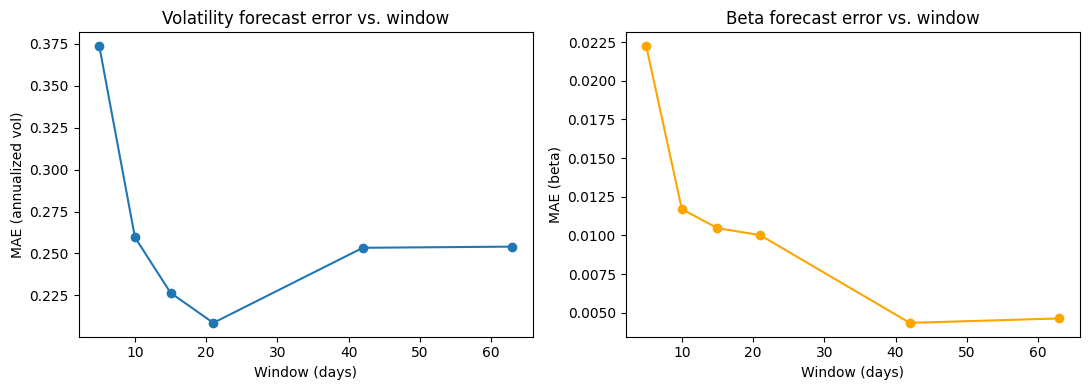

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
window_results["vol_forecast_MAE"].plot(ax=axes[0], marker="o")
axes[0].set_title("Volatility forecast error vs. window")
axes[0].set_xlabel("Window (days)")
axes[0].set_ylabel("MAE (annualized vol)")

window_results["beta_forecast_MAE"].plot(ax=axes[1], marker="o", color="orange")
axes[1].set_title("Beta forecast error vs. window")
axes[1].set_xlabel("Window (days)")
axes[1].set_ylabel("MAE (beta)")

fig.tight_layout()
plt.show()

## Sanity checks

In [7]:
assert window_results.isna().values.sum() == 0, "a candidate window produced no valid forecast-error observations -- widen the evaluation range"
assert WINNING_WINDOW in CANDIDATE_WINDOWS
print(f"Lever 0 sanity checks passed. WINNING_WINDOW = {WINNING_WINDOW}")

Lever 0 sanity checks passed. WINNING_WINDOW = 21
